# ECMWF Weather Forecast Verification and Renewable Energy Impact Analysis

## Objective

This project demonstrates how real weather forecast data can be processed and compared with observed weather data.

The project uses ECMWF forecast data for selected German locations and examines four forecast horizons: +6, +12, +24 and +48 hours. A small historical Berlin example is then used to demonstrate forecast verification and the possible effect of weather forecast errors on simplified wind and solar generation proxies.

## Setup

The main libraries are imported first. ecCodes is checked because it is required by cfgrib to read GRIB weather files.


In [1]:
from ecmwf.opendata import Client

import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


In [2]:
!python -m eccodes selfcheck


Found: ecCodes v2.48.0.
Library: C:\Users\prati\anaconda3\lib\site-packages\eccodes\eccodes.dll
Definitions: /MEMFS/definitions
Samples: /MEMFS/samples
Your system is ready.


## Loading and Inspecting an ECMWF GRIB Forecast

A single +24 hour temperature forecast is downloaded first. This provides a simple example of loading and inspecting a real GRIB file before working with several variables and forecast horizons.


In [3]:
client = Client(source="ecmwf")

result = client.retrieve(
    type="fc",
    step=24,
    param="2t",
    target="ecmwf_temperature_24h.grib2"
)

print("Forecast run:", result.datetime)


To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


20260917060000-24h-oper-fc.grib2:   0%|          | 0.00/640k [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
Forecast run: 2026-09-17 06:00:00


In [4]:
forecast_date = result.datetime.strftime("%Y-%m-%d")
forecast_hour = result.datetime.hour

print("Date used for the remaining live forecasts:", forecast_date)
print("Forecast initialization hour:", forecast_hour)


Date used for the remaining live forecasts: 2026-09-17
Forecast initialization hour: 6


In [5]:
ds = xr.open_dataset(
    "ecmwf_temperature_24h.grib2",
    engine="cfgrib"
)

ds


<xarray.Dataset>
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] ...
    step               timedelta64[ns] ...
    heightAboveGround  float64 ...
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         datetime64[ns] ...
Data variables:
    t2m                (latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-17T18:34 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
ds["t2m"]


<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)>
[1038240 values with dtype=float32]
Coordinates:
    time               datetime64[ns] 2026-09-17T06:00:00
    step               timedelta64[ns] 1 days
    heightAboveGround  float64 2.0
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         datetime64[ns] 2026-09-18T06:00:00
Attributes:
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              air_temperature
    GRIB_cfVarName:                           t2m
    GRIB_gridDefinitionDescription:           Latitude/longitude
    GRIB_iDirectionIncrementInDegrees:        0.25
    GRIB_iScansNegatively:                    0
    GRIB_jDirectionIncrementInDegrees:        0.25
    GRIB_jPointsAreConsecutive:               0
    GRIB_jScansPositively:                    0
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  180.0
    GRIB_longitudeOfLastGridPointInDegrees:   179.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                2 metre temperature
    GRIB_shortName:                           2t
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            air_temperature

In [7]:
temperature_c = ds["t2m"] - 273.15
temperature_c.attrs["units"] = "°C"

temperature_c


<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)>
array([[ -6.8042297,  -6.8042297,  -6.8042297, ...,  -6.8042297,
         -6.8042297,  -6.8042297],
       [ -7.8354797,  -7.8354797,  -7.8354797, ...,  -7.8354797,
         -7.8354797,  -7.8354797],
       [ -8.30423  ,  -8.30423  ,  -8.30423  , ...,  -8.27298  ,
         -8.30423  ,  -8.30423  ],
       ...,
       [-54.679214 , -54.679214 , -54.679214 , ..., -54.741714 ,
        -54.710464 , -54.710464 ],
       [-54.022964 , -54.022964 , -54.022964 , ..., -54.022964 ,
        -54.022964 , -54.022964 ],
       [-53.616714 , -53.616714 , -53.616714 , ..., -53.616714 ,
        -53.616714 , -53.616714 ]], dtype=float32)
Coordinates:
    time               datetime64[ns] 2026-09-17T06:00:00
    step               timedelta64[ns] 1 days
    heightAboveGround  float64 2.0
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         datetime64[ns] 2026-09-18T06:00:00
Attributes:
    units:    °C

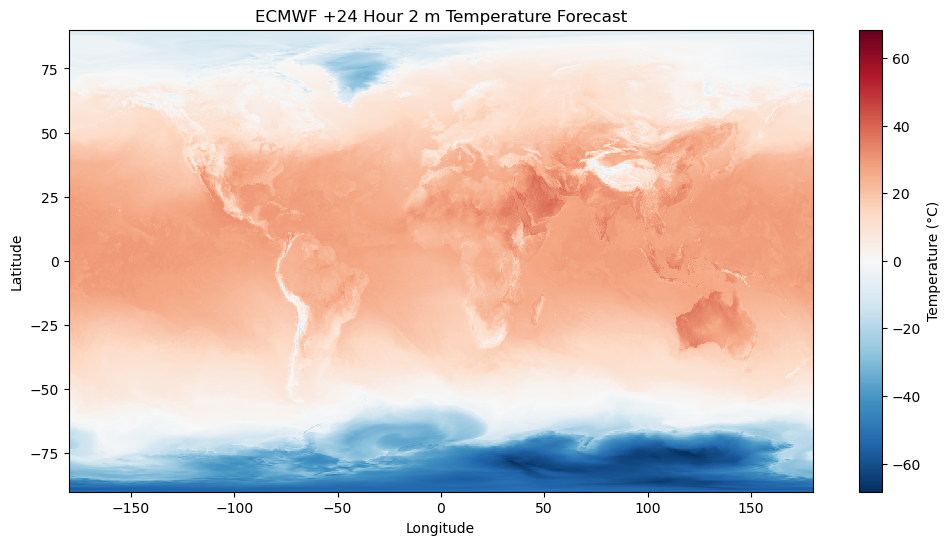

In [8]:
temperature_c.plot(
    figsize=(12, 6),
    cbar_kwargs={"label": "Temperature (°C)"}
)

plt.title("ECMWF +24 Hour 2 m Temperature Forecast")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## Germany Temperature Forecast

The ECMWF file contains a global grid. Since the project focuses on Germany, an approximate Germany bounding box is selected.

Three locations are then used in the forecast analysis: Berlin, Hamburg and Munich. Forecast values are taken from the nearest ECMWF grid point to each city.


In [9]:
germany_temp = temperature_c.sel(
    latitude=slice(55.5, 47.0),
    longitude=slice(5.0, 16.0)
)

germany_temp


<xarray.DataArray 't2m' (latitude: 35, longitude: 45)>
array([[14.94577  , 15.00827  , 15.07077  , ..., 15.63327  , 15.60202  ,
        15.50827  ],
       [15.19577  , 15.16452  , 15.22702  , ..., 15.50827  , 15.60202  ,
        15.63327  ],
       [15.38327  , 15.41452  , 15.47702  , ..., 15.69577  , 16.07077  ,
        16.10202  ],
       ...,
       [13.28952  , 13.32077  , 12.60202  , ...,  7.9457703,  7.0395203,
         9.22702  ],
       [13.57077  , 12.35202  , 11.91452  , ...,  9.97702  , 11.35202  ,
        11.16452  ],
       [12.57077  , 12.03952  , 11.82077  , ..., 11.07077  , 11.19577  ,
        11.69577  ]], dtype=float32)
Coordinates:
    time               datetime64[ns] 2026-09-17T06:00:00
    step               timedelta64[ns] 1 days
    heightAboveGround  float64 2.0
  * latitude           (latitude) float64 55.5 55.25 55.0 ... 47.5 47.25 47.0
  * longitude          (longitude) float64 5.0 5.25 5.5 5.75 ... 15.5 15.75 16.0
    valid_time         datetime64[ns] 2026-09-18T06:00:00
Attributes:
    units:    °C

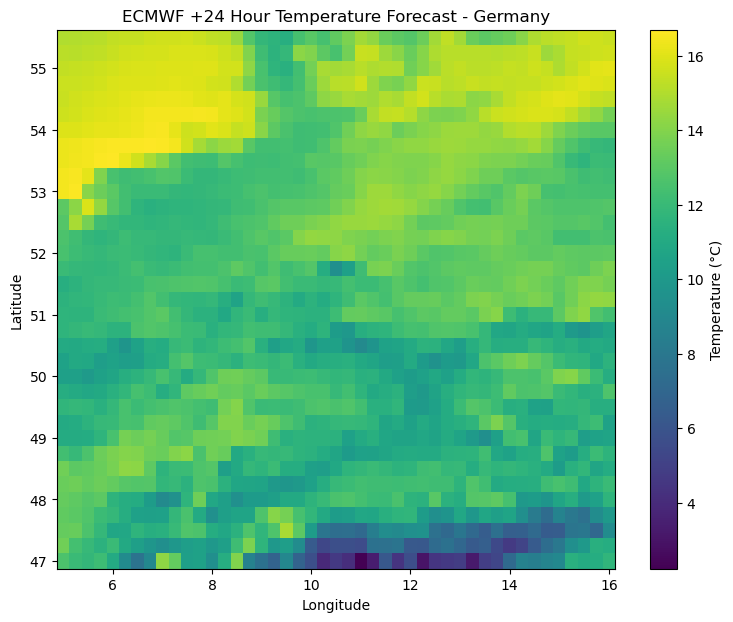

In [10]:
germany_temp.plot(
    figsize=(9, 7),
    cbar_kwargs={"label": "Temperature (°C)"}
)

plt.title("ECMWF +24 Hour Temperature Forecast - Germany")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [11]:
locations = {
    "Berlin": {
        "latitude": 52.52,
        "longitude": 13.41
    },
    "Hamburg": {
        "latitude": 53.55,
        "longitude": 9.99
    },
    "Munich": {
        "latitude": 48.14,
        "longitude": 11.58
    }
}


## Multiple Forecast Horizons

The live forecast analysis uses four lead times:

- +6 hours
- +12 hours
- +24 hours
- +48 hours

All weather variables are downloaded from the same ECMWF forecast initialization so that the timestamps remain aligned.


In [12]:
temperature_result = client.retrieve(
    date=forecast_date,
    time=forecast_hour,
    type="fc",
    step=[6, 12, 24, 48],
    param="2t",
    target="ecmwf_temperature_forecasts.grib2"
)

print("Forecast run:", temperature_result.datetime)


<multiple>:   0%|          | 0.00/2.50M [00:00<?, ?B/s]

Forecast run: 2026-09-17 06:00:00


In [13]:
temp_ds = xr.open_dataset(
    "ecmwf_temperature_forecasts.grib2",
    engine="cfgrib"
)

temp_ds


<xarray.Dataset>
Dimensions:            (step: 4, latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] ...
  * step               (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    heightAboveGround  float64 ...
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         (step) datetime64[ns] ...
Data variables:
    t2m                (step, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-17T18:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
temp_ds["step"].values


array([ 21600000000000,  43200000000000,  86400000000000, 172800000000000],
      dtype='timedelta64[ns]')

In [15]:
temp_c = temp_ds["t2m"] - 273.15
temp_c.attrs["units"] = "°C"

temp_c


<xarray.DataArray 't2m' (step: 4, latitude: 721, longitude: 1440)>
array([[[ -3.7119446,  -3.7119446,  -3.7119446, ...,  -3.7119446,
          -3.7119446,  -3.7119446],
        [ -3.7744446,  -3.7744446,  -3.7744446, ...,  -3.7744446,
          -3.7744446,  -3.7744446],
        [ -3.7431946,  -3.7431946,  -3.7431946, ...,  -3.7431946,
          -3.7431946,  -3.7431946],
        ...,
        [-54.52446  , -54.52446  , -54.55571  , ..., -54.52446  ,
         -54.52446  , -54.52446  ],
        [-56.33696  , -56.33696  , -56.33696  , ..., -56.30571  ,
         -56.30571  , -56.30571  ],
        [-54.77446  , -54.77446  , -54.77446  , ..., -54.77446  ,
         -54.77446  , -54.77446  ]],

       [[ -3.4008484,  -3.4008484,  -3.4008484, ...,  -3.4008484,
          -3.4008484,  -3.4008484],
        [ -3.4008484,  -3.4008484,  -3.4008484, ...,  -3.4008484,
          -3.4008484,  -3.4008484],
        [ -3.4320984,  -3.4320984,  -3.4320984, ...,  -3.4008484,
          -3.4320984,  -3.4320984],
...
        [-54.679214 , -54.679214 , -54.679214 , ..., -54.741714 ,
         -54.710464 , -54.710464 ],
        [-54.022964 , -54.022964 , -54.022964 , ..., -54.022964 ,
         -54.022964 , -54.022964 ],
        [-53.616714 , -53.616714 , -53.616714 , ..., -53.616714 ,
         -53.616714 , -53.616714 ]],

       [[-10.307831 , -10.307831 , -10.307831 , ..., -10.307831 ,
         -10.307831 , -10.307831 ],
        [-10.339081 , -10.339081 , -10.339081 , ..., -10.370331 ,
         -10.370331 , -10.370331 ],
        [ -9.526581 ,  -9.526581 ,  -9.526581 , ...,  -9.557831 ,
          -9.557831 ,  -9.557831 ],
        ...,
        [-57.995346 , -57.964096 , -57.964096 , ..., -58.089096 ,
         -58.057846 , -58.026596 ],
        [-56.776596 , -56.776596 , -56.776596 , ..., -56.807846 ,
         -56.807846 , -56.776596 ],
        [-57.651596 , -57.651596 , -57.651596 , ..., -57.651596 ,
         -57.651596 , -57.651596 ]]], dtype=float32)
Coordinates:
    time               datetime64[ns] 2026-09-17T06:00:00
  * step               (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    heightAboveGround  float64 2.0
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         (step) datetime64[ns] 2026-09-17T12:00:00 ... 2026-09-...
Attributes:
    units:    °C

In [16]:
temperature_records = []

for city, coords in locations.items():

    city_forecast = temp_c.sel(
        latitude=coords["latitude"],
        longitude=coords["longitude"],
        method="nearest"
    )

    for step in city_forecast.step:

        point = city_forecast.sel(step=step)

        lead_hours = int(
            pd.to_timedelta(step.values).total_seconds() / 3600
        )

        temperature_records.append({
            "location": city,
            "latitude": float(point.latitude.values),
            "longitude": float(point.longitude.values),
            "forecast_time": pd.to_datetime(point.time.values),
            "valid_time": pd.to_datetime(point.valid_time.values),
            "lead_hours": lead_hours,
            "temperature_forecast_c": round(float(point.values), 2)
        })


C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.


In [17]:
temperature_forecasts_df = pd.DataFrame(temperature_records)

temperature_forecasts_df


,location,latitude,longitude,forecast_time,valid_time,lead_hours,temperature_forecast_c
0,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,18.54
1,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,15.82
2,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-18 06:00:00,24,13.60
3,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-19 06:00:00,48,12.47
4,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 12:00:00,6,16.85
5,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 18:00:00,12,15.32
6,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-18 06:00:00,24,12.91
7,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-19 06:00:00,48,13.13
8,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,18.48
9,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,14.54


## Wind Speed Forecast

ECMWF provides 10 metre wind as two components:

- `10u`: east-west wind component
- `10v`: north-south wind component

Wind speed is calculated using:

\[
Wind\ Speed = \sqrt{u^2 + v^2}
\]


In [18]:
wind_result = client.retrieve(
    date=forecast_date,
    time=forecast_hour,
    type="fc",
    step=[6, 12, 24, 48],
    param=["10u", "10v"],
    target="ecmwf_wind_forecasts.grib2"
)

print("Forecast run:", wind_result.datetime)


<multiple>:   0%|          | 0.00/6.65M [00:00<?, ?B/s]

Forecast run: 2026-09-17 06:00:00


In [19]:
wind_ds = xr.open_dataset(
    "ecmwf_wind_forecasts.grib2",
    engine="cfgrib"
)

wind_ds


<xarray.Dataset>
Dimensions:            (step: 4, latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] ...
  * step               (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    heightAboveGround  float64 ...
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         (step) datetime64[ns] ...
Data variables:
    u10                (step, latitude, longitude) float32 ...
    v10                (step, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-17T18:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
wind_speed = np.sqrt(
    wind_ds["u10"]**2 +
    wind_ds["v10"]**2
)

wind_speed.name = "wind_speed"
wind_speed.attrs["units"] = "m/s"

wind_speed


<xarray.DataArray 'wind_speed' (step: 4, latitude: 721, longitude: 1440)>
array([[[8.851909 , 8.851909 , 8.851909 , ..., 8.851909 , 8.851909 ,
         8.851909 ],
        [9.163873 , 9.159942 , 9.14771  , ..., 9.141795 , 9.150473 ,
         9.154888 ],
        [9.359056 , 9.368315 , 9.364598 , ..., 9.349789 , 9.345544 ,
         9.363061 ],
        ...,
        [4.1452885, 4.1452885, 4.131402 , ..., 4.1735344, 4.1663375,
         4.152463 ],
        [2.6785216, 2.6658714, 2.6687016, ..., 2.691294 , 2.6758842,
         2.6785216],
        [4.615011 , 4.615011 , 4.615011 , ..., 4.615011 , 4.615011 ,
         4.615011 ]],

       [[7.1231456, 7.1231456, 7.1231456, ..., 7.1231456, 7.1231456,
         7.1231456],
        [7.425703 , 7.4269667, 7.414133 , ..., 7.4162   , 7.4170375,
         7.4180393],
        [7.61719  , 7.610278 , 7.610581 , ..., 7.617436 , 7.6171937,
         7.6171117],
...
        [4.916449 , 4.915616 , 4.899652 , ..., 4.904532 , 4.91871  ,
         4.9174805],
        [5.0500636, 5.0471673, 5.041516 , ..., 5.065242 , 5.059031 ,
         5.0559955],
        [3.916217 , 3.916217 , 3.916217 , ..., 3.916217 , 3.916217 ,
         3.916217 ]],

       [[5.0173836, 5.0173836, 5.0173836, ..., 5.0173836, 5.0173836,
         5.0173836],
        [5.0319943, 5.0443573, 5.041433 , ..., 5.0259104, 5.022781 ,
         5.035021 ],
        [5.668205 , 5.6672397, 5.6663175, ..., 5.6748967, 5.672495 ,
         5.6702642],
        ...,
        [8.8789   , 8.87151  , 8.848914 , ..., 8.84099  , 8.848216 ,
         8.855712 ],
        [8.896296 , 8.871011 , 8.864456 , ..., 8.924143 , 8.913505 ,
         8.906543 ],
        [7.644007 , 7.644007 , 7.644007 , ..., 7.644007 , 7.644007 ,
         7.644007 ]]], dtype=float32)
Coordinates:
    time               datetime64[ns] 2026-09-17T06:00:00
  * step               (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    heightAboveGround  float64 10.0
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time         (step) datetime64[ns] 2026-09-17T12:00:00 ... 2026-09-...
Attributes:
    units:    m/s

In [21]:
wind_records = []

for city, coords in locations.items():

    city_wind = wind_speed.sel(
        latitude=coords["latitude"],
        longitude=coords["longitude"],
        method="nearest"
    )

    for step in city_wind.step:

        point = city_wind.sel(step=step)

        lead_hours = int(
            pd.to_timedelta(step.values).total_seconds() / 3600
        )

        wind_records.append({
            "location": city,
            "latitude": float(point.latitude.values),
            "longitude": float(point.longitude.values),
            "forecast_time": pd.to_datetime(point.time.values),
            "valid_time": pd.to_datetime(point.valid_time.values),
            "lead_hours": lead_hours,
            "wind_speed_forecast_ms": round(float(point.values), 2)
        })

wind_forecasts_df = pd.DataFrame(wind_records)

wind_forecasts_df


C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.


,location,latitude,longitude,forecast_time,valid_time,lead_hours,wind_speed_forecast_ms
0,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,3.73
1,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,2.64
2,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-18 06:00:00,24,2.70
3,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-19 06:00:00,48,3.36
4,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 12:00:00,6,5.21
5,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 18:00:00,12,4.96
6,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-18 06:00:00,24,3.87
7,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-19 06:00:00,48,4.91
8,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,2.78
9,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,1.19


## Total Cloud Cover Forecast

Total cloud cover is relevant to solar-energy applications because cloudiness affects how much solar radiation reaches the surface.

The GRIB values are inspected before conversion because cloud cover may be represented as a fraction rather than a percentage.


In [22]:
cloud_result = client.retrieve(
    date=forecast_date,
    time=forecast_hour,
    type="fc",
    step=[6, 12, 24, 48],
    param="tcc",
    target="ecmwf_cloud_forecasts.grib2"
)

print("Forecast run:", cloud_result.datetime)


<multiple>:   0%|          | 0.00/2.19M [00:00<?, ?B/s]

Forecast run: 2026-09-17 06:00:00


In [23]:
cloud_ds = xr.open_dataset(
    "ecmwf_cloud_forecasts.grib2",
    engine="cfgrib"
)

cloud_ds


<xarray.Dataset>
Dimensions:           (step: 4, latitude: 721, longitude: 1440)
Coordinates:
    time              datetime64[ns] ...
  * step              (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    entireAtmosphere  float64 ...
  * latitude          (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude         (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time        (step) datetime64[ns] ...
Data variables:
    tcc               (step, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-17T18:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [24]:
print("Units:", cloud_ds["tcc"].attrs.get("units"))
print("Minimum:", float(cloud_ds["tcc"].min()))
print("Maximum:", float(cloud_ds["tcc"].max()))


Units: (0 - 1)
Minimum: 0.0
Maximum: 1.0


In [25]:
cloud_cover = cloud_ds["tcc"].copy()

if float(cloud_cover.max()) <= 1.5:
    cloud_cover = cloud_cover * 100

cloud_cover.name = "cloud_cover"
cloud_cover.attrs["units"] = "%"

cloud_cover


<xarray.DataArray 'cloud_cover' (step: 4, latitude: 721, longitude: 1440)>
array([[[100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        ...,
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ]],

       [[100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
...
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ]],

       [[100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        [100.     , 100.     , 100.     , ..., 100.     , 100.     ,
         100.     ],
        ...,
        [ 82.03125,  82.03125,  82.03125, ...,  82.8125 ,  82.8125 ,
          82.03125],
        [ 67.1875 ,  67.1875 ,  67.1875 , ...,  67.1875 ,  67.1875 ,
          67.1875 ],
        [  6.25   ,   6.25   ,   6.25   , ...,   6.25   ,   6.25   ,
           6.25   ]]], dtype=float32)
Coordinates:
    time              datetime64[ns] 2026-09-17T06:00:00
  * step              (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    entireAtmosphere  float64 0.0
  * latitude          (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude         (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time        (step) datetime64[ns] 2026-09-17T12:00:00 ... 2026-09-1...
Attributes:
    units:    %

In [26]:
cloud_records = []

for city, coords in locations.items():

    city_cloud = cloud_cover.sel(
        latitude=coords["latitude"],
        longitude=coords["longitude"],
        method="nearest"
    )

    for step in city_cloud.step:

        point = city_cloud.sel(step=step)

        lead_hours = int(
            pd.to_timedelta(step.values).total_seconds() / 3600
        )

        cloud_records.append({
            "location": city,
            "latitude": float(point.latitude.values),
            "longitude": float(point.longitude.values),
            "forecast_time": pd.to_datetime(point.time.values),
            "valid_time": pd.to_datetime(point.valid_time.values),
            "lead_hours": lead_hours,
            "cloud_cover_forecast_pct": round(float(point.values), 2)
        })

cloud_forecasts_df = pd.DataFrame(cloud_records)

cloud_forecasts_df


C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.


,location,latitude,longitude,forecast_time,valid_time,lead_hours,cloud_cover_forecast_pct
0,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,92.19
1,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,94.53
2,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-18 06:00:00,24,100.00
3,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-19 06:00:00,48,78.12
4,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 12:00:00,6,100.00
5,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 18:00:00,12,98.44
6,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-18 06:00:00,24,15.62
7,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-19 06:00:00,48,100.00
8,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,77.34
9,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,46.09


## Solar Radiation Forecast

ECMWF surface solar radiation downwards (`ssrd`) is stored as accumulated energy.

To make the values easier to interpret, consecutive 6-hour accumulations are converted into average radiation in W/m². Extra 6-hour steps are downloaded so that the +24 and +48 hour intervals can be calculated consistently.


In [27]:
solar_result = client.retrieve(
    date=forecast_date,
    time=forecast_hour,
    type="fc",
    step=[6, 12, 18, 24, 30, 36, 42, 48],
    param="ssrd",
    target="ecmwf_solar_forecasts.grib2"
)

print("Forecast run:", solar_result.datetime)


<multiple>:   0%|          | 0.00/9.58M [00:00<?, ?B/s]

Forecast run: 2026-09-17 06:00:00


In [28]:
solar_ds = xr.open_dataset(
    "ecmwf_solar_forecasts.grib2",
    engine="cfgrib"
)

solar_ds


<xarray.Dataset>
Dimensions:     (step: 8, latitude: 721, longitude: 1440)
Coordinates:
    time        datetime64[ns] ...
  * step        (step) timedelta64[ns] 0 days 06:00:00 ... 2 days 00:00:00
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    valid_time  (step) datetime64[ns] ...
Data variables:
    ssrd        (step, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-17T18:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [29]:
solar_ds["ssrd"]


<xarray.DataArray 'ssrd' (step: 8, latitude: 721, longitude: 1440)>
[8305920 values with dtype=float32]
Coordinates:
    time        datetime64[ns] 2026-09-17T06:00:00
  * step        (step) timedelta64[ns] 0 days 06:00:00 ... 2 days 00:00:00
    surface     float64 0.0
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    valid_time  (step) datetime64[ns] 2026-09-17T12:00:00 ... 2026-09-19T06:0...
Attributes:
    GRIB_paramId:                             169
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              surface_downwelling_shortwave_f...
    GRIB_cfVarName:                           ssrd
    GRIB_gridDefinitionDescription:           Latitude/longitude
    GRIB_iDirectionIncrementInDegrees:        0.25
    GRIB_iScansNegatively:                    0
    GRIB_jDirectionIncrementInDegrees:        0.25
    GRIB_jPointsAreConsecutive:               0
    GRIB_jScansPositively:                    0
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  180.0
    GRIB_longitudeOfLastGridPointInDegrees:   179.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Surface short-wave (solar) radi...
    GRIB_shortName:                           ssrd
    GRIB_units:                               J m**-2
    long_name:                                Surface short-wave (solar) radi...
    units:                                    J m**-2
    standard_name:                            surface_downwelling_shortwave_f...

In [30]:
ssrd = solar_ds["ssrd"]

interval_energy = ssrd.copy()

# First interval: forecast start to +6 hours
interval_energy[0] = ssrd.isel(step=0)

# Later intervals: current accumulation minus previous accumulation
interval_energy[1:] = ssrd.diff(dim="step").values

interval_seconds = 6 * 3600
solar_flux = interval_energy / interval_seconds

solar_flux.name = "solar_radiation"
solar_flux.attrs["units"] = "W/m²"


In [31]:
print(solar_flux.step.values)
print(solar_flux.valid_time.values)


[ 21600000000000  43200000000000  64800000000000  86400000000000
 108000000000000 129600000000000 151200000000000 172800000000000]
['2026-09-17T12:00:00.000000000' '2026-09-17T18:00:00.000000000'
 '2026-09-18T00:00:00.000000000' '2026-09-18T06:00:00.000000000'
 '2026-09-18T12:00:00.000000000' '2026-09-18T18:00:00.000000000'
 '2026-09-19T00:00:00.000000000' '2026-09-19T06:00:00.000000000']


In [32]:
selected_steps = pd.to_timedelta(
    [6, 12, 24, 48],
    unit="h"
)

solar_selected = solar_flux.sel(step=selected_steps)

solar_selected


<xarray.DataArray 'solar_radiation' (step: 4, latitude: 721, longitude: 1440)>
array([[[15.73926 , 15.73926 , 15.73926 , ..., 15.73926 , 15.73926 ,
         15.73926 ],
        [14.293333, 14.293333, 14.293333, ..., 14.317037, 14.293333,
         14.293333],
        [12.681481, 12.681481, 12.657778, ..., 12.705185, 12.681481,
         12.681481],
        ...,
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ]],

       [[14.127407, 14.127407, 14.127407, ..., 14.127407, 14.127407,
         14.127407],
        [12.136296, 12.136296, 12.136296, ..., 12.112593, 12.136296,
         12.136296],
        [10.358519, 10.358519, 10.405926, ..., 10.311111, 10.334815,
         10.334815],
...
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ]],

       [[11.52    , 11.52    , 11.52    , ..., 11.52    , 11.52    ,
         11.52    ],
        [12.657778, 12.657778, 12.657778, ..., 12.705185, 12.705185,
         12.705185],
        [13.131852, 13.084444, 13.131852, ..., 13.179259, 13.131852,
         13.131852],
        ...,
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ]]], dtype=float32)
Coordinates:
    time        datetime64[ns] 2026-09-17T06:00:00
  * step        (step) timedelta64[ns] 06:00:00 12:00:00 1 days 2 days
    surface     float64 0.0
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    valid_time  (step) datetime64[ns] 2026-09-17T12:00:00 ... 2026-09-19T06:0...
Attributes:
    units:    W/m²

In [33]:
solar_records = []

for city, coords in locations.items():

    city_solar = solar_selected.sel(
        latitude=coords["latitude"],
        longitude=coords["longitude"],
        method="nearest"
    )

    for step in city_solar.step:

        point = city_solar.sel(step=step)

        lead_hours = int(
            pd.to_timedelta(step.values).total_seconds() / 3600
        )

        solar_records.append({
            "location": city,
            "latitude": float(point.latitude.values),
            "longitude": float(point.longitude.values),
            "forecast_time": pd.to_datetime(point.time.values),
            "valid_time": pd.to_datetime(point.valid_time.values),
            "lead_hours": lead_hours,
            "solar_radiation_forecast_wm2": round(float(point.values), 2)
        })

solar_forecasts_df = pd.DataFrame(solar_records)

solar_forecasts_df


C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
C:\Users\prati\anaconda3\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.


,location,latitude,longitude,forecast_time,valid_time,lead_hours,solar_radiation_forecast_wm2
0,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,435.11
1,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,229.74
2,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-18 06:00:00,24,3.60
3,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-19 06:00:00,48,9.67
4,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 12:00:00,6,263.61
5,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 18:00:00,12,132.43
6,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-18 06:00:00,24,6.09
7,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-19 06:00:00,48,3.13
8,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,467.29
9,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,284.66


## Combined ECMWF Forecast Dataset

The four forecast tables are merged using location, forecast initialization, valid time and lead time. This creates one table for the live forecast section.


In [34]:
merge_columns = [
    "location",
    "latitude",
    "longitude",
    "forecast_time",
    "valid_time",
    "lead_hours"
]

ecmwf_forecasts_df = temperature_forecasts_df.merge(
    wind_forecasts_df,
    on=merge_columns
)

ecmwf_forecasts_df = ecmwf_forecasts_df.merge(
    cloud_forecasts_df,
    on=merge_columns
)

ecmwf_forecasts_df = ecmwf_forecasts_df.merge(
    solar_forecasts_df,
    on=merge_columns
)


In [35]:
ecmwf_forecasts_df


,location,latitude,longitude,forecast_time,valid_time,lead_hours,temperature_forecast_c,wind_speed_forecast_ms,cloud_cover_forecast_pct,solar_radiation_forecast_wm2
0,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,18.54,3.73,92.19,435.11
1,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,15.82,2.64,94.53,229.74
2,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-18 06:00:00,24,13.60,2.70,100.00,3.60
3,Berlin,52.50,13.5,2026-09-17 06:00:00,2026-09-19 06:00:00,48,12.47,3.36,78.12,9.67
4,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 12:00:00,6,16.85,5.21,100.00,263.61
5,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-17 18:00:00,12,15.32,4.96,98.44,132.43
6,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-18 06:00:00,24,12.91,3.87,15.62,6.09
7,Hamburg,53.50,10.0,2026-09-17 06:00:00,2026-09-19 06:00:00,48,13.13,4.91,100.00,3.13
8,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 12:00:00,6,18.48,2.78,77.34,467.29
9,Munich,48.25,11.5,2026-09-17 06:00:00,2026-09-17 18:00:00,12,14.54,1.19,46.09,284.66


In [36]:
print("Shape:", ecmwf_forecasts_df.shape)
print()
print(ecmwf_forecasts_df.isna().sum())


Shape: (12, 10)

location                        0
latitude                        0
longitude                       0
forecast_time                   0
valid_time                      0
lead_hours                      0
temperature_forecast_c          0
wind_speed_forecast_ms          0
cloud_cover_forecast_pct        0
solar_radiation_forecast_wm2    0
dtype: int64


In [37]:
ecmwf_forecasts_df.to_csv(
    "ecmwf_forecasts.csv",
    index=False
)


## Historical Forecast Verification

The live ECMWF section demonstrates GRIB processing, but a future forecast cannot be verified until observations become available.

For a small student-level verification example, one archived ECMWF forecast run from 1 September 2025 is used for Berlin. The four lead times are compared with observed weather at the corresponding valid times.

This is a demonstration of the verification method, not a comprehensive assessment of ECMWF forecast skill.


### Historical ECMWF Forecast Sample - Berlin

The archived forecast is retrieved for the 00:00 UTC run on 1 September 2025. Temperature, wind speed, cloud cover and shortwave radiation are requested together.


In [38]:
import requests


In [39]:
historical_run = "2025-09-01T00:00"

berlin_lat = 52.52
berlin_lon = 13.41

historical_url = "https://single-runs-api.open-meteo.com/v1/forecast"


In [40]:
params = {
    "latitude": berlin_lat,
    "longitude": berlin_lon,
    "run": historical_run,
    "models": "ecmwf_ifs",
    "hourly": [
        "temperature_2m",
        "wind_speed_10m",
        "cloud_cover",
        "shortwave_radiation"
    ],
    "wind_speed_unit": "ms",
    "forecast_hours": 49,
    "timezone": "GMT"
}

response = requests.get(
    historical_url,
    params=params
)

print("Status code:", response.status_code)


Status code: 200


In [41]:
data = response.json()

data["hourly_units"]


{'time': 'iso8601',
 'temperature_2m': '°C',
 'wind_speed_10m': 'm/s',
 'cloud_cover': '%',
 'shortwave_radiation': 'W/m²'}

In [42]:
historical_berlin_df = pd.DataFrame(
    data["hourly"]
)

historical_berlin_df.head()


,time,temperature_2m,wind_speed_10m,cloud_cover,shortwave_radiation
0,2025-09-01T00:00,16.0,2.73,0,NaN
1,2025-09-01T01:00,15.3,2.60,0,0.0
2,2025-09-01T02:00,15.2,2.65,0,0.0
3,2025-09-01T03:00,15.0,2.86,0,0.0
4,2025-09-01T04:00,14.8,2.93,0,0.0


In [43]:
historical_berlin_df["time"] = pd.to_datetime(
    historical_berlin_df["time"]
)

historical_berlin_df.head()


,time,temperature_2m,wind_speed_10m,cloud_cover,shortwave_radiation
0,2025-09-01 00:00:00,16.0,2.73,0,NaN
1,2025-09-01 01:00:00,15.3,2.60,0,0.0
2,2025-09-01 02:00:00,15.2,2.65,0,0.0
3,2025-09-01 03:00:00,15.0,2.86,0,0.0
4,2025-09-01 04:00:00,14.8,2.93,0,0.0


In [44]:
forecast_init = pd.Timestamp("2025-09-01 00:00:00")

historical_berlin_df["lead_hours"] = (
    historical_berlin_df["time"] - forecast_init
).dt.total_seconds() / 3600


In [45]:
historical_berlin_df[
    ["time", "lead_hours"]
].head(15)


,time,lead_hours
0,2025-09-01 00:00:00,0.0
1,2025-09-01 01:00:00,1.0
2,2025-09-01 02:00:00,2.0
3,2025-09-01 03:00:00,3.0
4,2025-09-01 04:00:00,4.0
5,2025-09-01 05:00:00,5.0
6,2025-09-01 06:00:00,6.0
7,2025-09-01 07:00:00,7.0
8,2025-09-01 08:00:00,8.0
9,2025-09-01 09:00:00,9.0


In [46]:
historical_berlin_selected = historical_berlin_df[
    historical_berlin_df["lead_hours"].isin(
        [6, 12, 24, 48]
    )
].copy()

historical_berlin_selected["lead_hours"] = (
    historical_berlin_selected["lead_hours"].astype(int)
)

historical_berlin_selected


,time,temperature_2m,wind_speed_10m,cloud_cover,shortwave_radiation,lead_hours
6,2025-09-01 06:00:00,16.0,3.07,0,119.0,6
12,2025-09-01 12:00:00,25.9,4.84,100,688.0,12
24,2025-09-02 00:00:00,18.1,2.10,100,0.0,24
48,2025-09-03 00:00:00,15.5,1.81,0,0.0,48


In [47]:
historical_berlin_selected = historical_berlin_selected.rename(
    columns={
        "time": "valid_time",
        "temperature_2m": "temperature_forecast_c",
        "wind_speed_10m": "wind_speed_forecast_ms",
        "cloud_cover": "cloud_cover_forecast_pct",
        "shortwave_radiation": "solar_radiation_forecast_wm2"
    }
)

historical_berlin_selected["location"] = "Berlin"
historical_berlin_selected["forecast_time"] = forecast_init


In [48]:
historical_berlin_selected[
    [
        "location",
        "forecast_time",
        "valid_time",
        "lead_hours",
        "temperature_forecast_c",
        "wind_speed_forecast_ms",
        "cloud_cover_forecast_pct",
        "solar_radiation_forecast_wm2"
    ]
]


,location,forecast_time,valid_time,lead_hours,temperature_forecast_c,wind_speed_forecast_ms,cloud_cover_forecast_pct,solar_radiation_forecast_wm2
6,Berlin,2025-09-01,2025-09-01 06:00:00,6,16.0,3.07,0,119.0
12,Berlin,2025-09-01,2025-09-01 12:00:00,12,25.9,4.84,100,688.0
24,Berlin,2025-09-01,2025-09-02 00:00:00,24,18.1,2.10,100,0.0
48,Berlin,2025-09-01,2025-09-03 00:00:00,48,15.5,1.81,0,0.0


## Observed Weather Data

Observed weather data are obtained from Deutscher Wetterdienst (DWD) through the Bright Sky API.

The observation range covers 1-3 September 2025 so that the +6, +12, +24 and +48 hour forecast valid times can all be matched.


In [49]:
observed_url = "https://api.brightsky.dev/weather"

observed_params = {
    "lat": 52.52,
    "lon": 13.41,
    "date": "2025-09-01",
    "last_date": "2025-09-03"
}

response = requests.get(
    observed_url,
    params=observed_params
)

print("Status code:", response.status_code)

observed_data = response.json()

observed_berlin_df = pd.DataFrame(
    observed_data["weather"]
)

observed_berlin_df.head()


Status code: 200


,timestamp,source_id,precipitation,pressure_msl,sunshine,temperature,wind_direction,wind_speed,cloud_cover,dew_point,relative_humidity,visibility,wind_gust_direction,wind_gust_speed,condition,precipitation_probability,precipitation_probability_6h,solar,fallback_source_ids,icon
0,2025-09-01T00:00:00+00:00,312070,0.0,1011.5,0.0,16.2,120,9.4,0,12.2,77,55750,120,13.7,dry,None,None,0.0,"{'cloud_cover': 303712, 'relative_humidity': 3...",clear-night
1,2025-09-01T01:00:00+00:00,312070,0.0,1011.6,0.0,15.8,120,9.0,0,12.3,79,56140,120,13.0,dry,None,None,0.0,"{'cloud_cover': 303712, 'relative_humidity': 3...",clear-night
2,2025-09-01T02:00:00+00:00,312070,0.0,1011.2,0.0,15.5,120,10.4,0,12.3,81,48320,120,15.1,dry,None,None,0.0,"{'cloud_cover': 303712, 'relative_humidity': 3...",clear-night
3,2025-09-01T03:00:00+00:00,312070,0.0,1010.8,0.0,15.3,120,10.8,0,12.3,82,53540,110,15.8,dry,None,None,0.0,"{'cloud_cover': 303712, 'relative_humidity': 3...",clear-night
4,2025-09-01T04:00:00+00:00,312070,0.0,1010.4,0.0,14.7,120,10.1,0,12.3,85,48370,130,15.1,dry,None,None,0.0,"{'cloud_cover': 303712, 'relative_humidity': 3...",clear-night


In [50]:
observed_berlin_df.columns


Index(['timestamp', 'source_id', 'precipitation', 'pressure_msl', 'sunshine',
       'temperature', 'wind_direction', 'wind_speed', 'cloud_cover',
       'dew_point', 'relative_humidity', 'visibility', 'wind_gust_direction',
       'wind_gust_speed', 'condition', 'precipitation_probability',
       'precipitation_probability_6h', 'solar', 'fallback_source_ids', 'icon'],
      dtype='object')

In [51]:
observed_berlin_clean = observed_berlin_df[
    [
        "timestamp",
        "temperature",
        "wind_speed",
        "cloud_cover",
        "solar"
    ]
].copy()


In [52]:
observed_berlin_clean["timestamp"] = pd.to_datetime(
    observed_berlin_clean["timestamp"]
)

# Bright Sky wind speed is converted from km/h to m/s
observed_berlin_clean["wind_speed_ms"] = (
    observed_berlin_clean["wind_speed"] / 3.6
)

# Bright Sky solar is hourly energy in kWh/m².
# Over one hour, multiplying by 1000 gives the equivalent average W/m².
observed_berlin_clean["solar_wm2"] = (
    observed_berlin_clean["solar"] * 1000
)

# Remove timezone information so timestamps match the historical forecast table
observed_berlin_clean["timestamp"] = (
    observed_berlin_clean["timestamp"]
    .dt.tz_localize(None)
)


In [53]:
observed_berlin_clean = observed_berlin_clean[
    [
        "timestamp",
        "temperature",
        "wind_speed_ms",
        "cloud_cover",
        "solar_wm2"
    ]
]

observed_berlin_clean.head()


,timestamp,temperature,wind_speed_ms,cloud_cover,solar_wm2
0,2025-09-01 00:00:00,16.2,2.611111,0,0.0
1,2025-09-01 01:00:00,15.8,2.500000,0,0.0
2,2025-09-01 02:00:00,15.5,2.888889,0,0.0
3,2025-09-01 03:00:00,15.3,3.000000,0,0.0
4,2025-09-01 04:00:00,14.7,2.805556,0,0.0


In [54]:
selected_times = pd.to_datetime([
    "2025-09-01 06:00:00",
    "2025-09-01 12:00:00",
    "2025-09-02 00:00:00",
    "2025-09-03 00:00:00"
])

observed_berlin_selected = observed_berlin_clean[
    observed_berlin_clean["timestamp"].isin(selected_times)
].copy()

observed_berlin_selected


,timestamp,temperature,wind_speed_ms,cloud_cover,solar_wm2
6,2025-09-01 06:00:00,16.5,3.305556,0,110.0
12,2025-09-01 12:00:00,25.6,4.500000,87,585.0
24,2025-09-02 00:00:00,17.5,2.500000,100,0.0
48,2025-09-03 00:00:00,16.8,2.194444,75,0.0


In [55]:
observed_berlin_selected = observed_berlin_selected.rename(
    columns={
        "timestamp": "valid_time",
        "temperature": "temperature_observed_c",
        "wind_speed_ms": "wind_speed_observed_ms",
        "cloud_cover": "cloud_cover_observed_pct",
        "solar_wm2": "solar_radiation_observed_wm2"
    }
)


## Forecast and Observation Matching

Forecasts and observations are matched using `valid_time`. This is important because a +24 hour forecast must be compared with the observation 24 hours after the forecast initialization, not with the initialization time itself.


In [56]:
berlin_verification = historical_berlin_selected.merge(
    observed_berlin_selected[
        [
            "valid_time",
            "temperature_observed_c",
            "wind_speed_observed_ms",
            "cloud_cover_observed_pct",
            "solar_radiation_observed_wm2"
        ]
    ],
    on="valid_time"
)

print("Matched rows:", len(berlin_verification))

berlin_verification


Matched rows: 4


,valid_time,temperature_forecast_c,wind_speed_forecast_ms,cloud_cover_forecast_pct,solar_radiation_forecast_wm2,lead_hours,location,forecast_time,temperature_observed_c,wind_speed_observed_ms,cloud_cover_observed_pct,solar_radiation_observed_wm2
0,2025-09-01 06:00:00,16.0,3.07,0,119.0,6,Berlin,2025-09-01,16.5,3.305556,0,110.0
1,2025-09-01 12:00:00,25.9,4.84,100,688.0,12,Berlin,2025-09-01,25.6,4.500000,87,585.0
2,2025-09-02 00:00:00,18.1,2.10,100,0.0,24,Berlin,2025-09-01,17.5,2.500000,100,0.0
3,2025-09-03 00:00:00,15.5,1.81,0,0.0,48,Berlin,2025-09-01,16.8,2.194444,75,0.0


In [57]:
berlin_verification["temperature_error"] = (
    berlin_verification["temperature_forecast_c"]
    - berlin_verification["temperature_observed_c"]
)

berlin_verification["wind_error"] = (
    berlin_verification["wind_speed_forecast_ms"]
    - berlin_verification["wind_speed_observed_ms"]
)

berlin_verification["cloud_error"] = (
    berlin_verification["cloud_cover_forecast_pct"]
    - berlin_verification["cloud_cover_observed_pct"]
)

berlin_verification["solar_error"] = (
    berlin_verification["solar_radiation_forecast_wm2"]
    - berlin_verification["solar_radiation_observed_wm2"]
)


In [58]:
berlin_verification[
    [
        "lead_hours",
        "valid_time",
        "temperature_forecast_c",
        "temperature_observed_c",
        "temperature_error",
        "wind_speed_forecast_ms",
        "wind_speed_observed_ms",
        "wind_error",
        "cloud_cover_forecast_pct",
        "cloud_cover_observed_pct",
        "cloud_error",
        "solar_radiation_forecast_wm2",
        "solar_radiation_observed_wm2",
        "solar_error"
    ]
]


,lead_hours,valid_time,temperature_forecast_c,temperature_observed_c,temperature_error,wind_speed_forecast_ms,wind_speed_observed_ms,wind_error,cloud_cover_forecast_pct,cloud_cover_observed_pct,cloud_error,solar_radiation_forecast_wm2,solar_radiation_observed_wm2,solar_error
0,6,2025-09-01 06:00:00,16.0,16.5,-0.5,3.07,3.305556,-0.235556,0,0,0,119.0,110.0,9.0
1,12,2025-09-01 12:00:00,25.9,25.6,0.3,4.84,4.500000,0.340000,100,87,13,688.0,585.0,103.0
2,24,2025-09-02 00:00:00,18.1,17.5,0.6,2.10,2.500000,-0.400000,100,100,0,0.0,0.0,0.0
3,48,2025-09-03 00:00:00,15.5,16.8,-1.3,1.81,2.194444,-0.384444,0,75,-75,0.0,0.0,0.0


## Forecast Verification Metrics

Four basic metrics are used:

- **MAE**: average absolute forecast error
- **RMSE**: gives more weight to larger errors
- **Bias**: shows whether forecasts are generally too high or too low
- **Correlation**: shows how similarly forecast and observed values vary

Only four forecast cases are available in this demonstration, so the correlation values should be interpreted cautiously.


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [60]:
temp_mae = mean_absolute_error(
    berlin_verification["temperature_observed_c"],
    berlin_verification["temperature_forecast_c"]
)

temp_rmse = np.sqrt(mean_squared_error(
    berlin_verification["temperature_observed_c"],
    berlin_verification["temperature_forecast_c"]
))

temp_bias = berlin_verification["temperature_error"].mean()

temp_corr = berlin_verification[
    ["temperature_forecast_c", "temperature_observed_c"]
].corr().iloc[0, 1]

print("Temperature MAE:", round(temp_mae, 2), "°C")
print("Temperature RMSE:", round(temp_rmse, 2), "°C")
print("Temperature Bias:", round(temp_bias, 2), "°C")
print("Temperature Correlation:", round(temp_corr, 2))


Temperature MAE: 0.67 °C
Temperature RMSE: 0.77 °C
Temperature Bias: -0.23 °C
Temperature Correlation: 0.99


In [61]:
wind_mae = mean_absolute_error(
    berlin_verification["wind_speed_observed_ms"],
    berlin_verification["wind_speed_forecast_ms"]
)

wind_rmse = np.sqrt(mean_squared_error(
    berlin_verification["wind_speed_observed_ms"],
    berlin_verification["wind_speed_forecast_ms"]
))

wind_bias = berlin_verification["wind_error"].mean()

wind_corr = berlin_verification[
    ["wind_speed_forecast_ms", "wind_speed_observed_ms"]
].corr().iloc[0, 1]

print("Wind MAE:", round(wind_mae, 2), "m/s")
print("Wind RMSE:", round(wind_rmse, 2), "m/s")
print("Wind Bias:", round(wind_bias, 2), "m/s")
print("Wind Correlation:", round(wind_corr, 2))


Wind MAE: 0.34 m/s
Wind RMSE: 0.35 m/s
Wind Bias: -0.17 m/s
Wind Correlation: 1.0


In [62]:
cloud_mae = mean_absolute_error(
    berlin_verification["cloud_cover_observed_pct"],
    berlin_verification["cloud_cover_forecast_pct"]
)

cloud_rmse = np.sqrt(mean_squared_error(
    berlin_verification["cloud_cover_observed_pct"],
    berlin_verification["cloud_cover_forecast_pct"]
))

cloud_bias = berlin_verification["cloud_error"].mean()

cloud_corr = berlin_verification[
    ["cloud_cover_forecast_pct", "cloud_cover_observed_pct"]
].corr().iloc[0, 1]

print("Cloud MAE:", round(cloud_mae, 2), "percentage points")
print("Cloud RMSE:", round(cloud_rmse, 2), "percentage points")
print("Cloud Bias:", round(cloud_bias, 2), "percentage points")
print("Cloud Correlation:", round(cloud_corr, 2))


Cloud MAE: 22.0 percentage points
Cloud RMSE: 38.06 percentage points
Cloud Bias: -15.5 percentage points
Cloud Correlation: 0.72


In [63]:
solar_mae = mean_absolute_error(
    berlin_verification["solar_radiation_observed_wm2"],
    berlin_verification["solar_radiation_forecast_wm2"]
)

solar_rmse = np.sqrt(mean_squared_error(
    berlin_verification["solar_radiation_observed_wm2"],
    berlin_verification["solar_radiation_forecast_wm2"]
))

solar_bias = berlin_verification["solar_error"].mean()

solar_corr = berlin_verification[
    ["solar_radiation_forecast_wm2", "solar_radiation_observed_wm2"]
].corr().iloc[0, 1]

print("Solar MAE:", round(solar_mae, 2), "W/m²")
print("Solar RMSE:", round(solar_rmse, 2), "W/m²")
print("Solar Bias:", round(solar_bias, 2), "W/m²")
print("Solar Correlation:", round(solar_corr, 2))


Solar MAE: 28.0 W/m²
Solar RMSE: 51.7 W/m²
Solar Bias: 28.0 W/m²
Solar Correlation: 1.0


In [64]:
verification_summary = pd.DataFrame({
    "Variable": [
        "Temperature",
        "Wind Speed",
        "Cloud Cover",
        "Solar Radiation"
    ],
    "Unit": [
        "°C",
        "m/s",
        "percentage points",
        "W/m²"
    ],
    "MAE": [
        temp_mae,
        wind_mae,
        cloud_mae,
        solar_mae
    ],
    "RMSE": [
        temp_rmse,
        wind_rmse,
        cloud_rmse,
        solar_rmse
    ],
    "Bias": [
        temp_bias,
        wind_bias,
        cloud_bias,
        solar_bias
    ],
    "Correlation": [
        temp_corr,
        wind_corr,
        cloud_corr,
        solar_corr
    ]
})

verification_summary[
    ["MAE", "RMSE", "Bias", "Correlation"]
] = verification_summary[
    ["MAE", "RMSE", "Bias", "Correlation"]
].round(2)

verification_summary


,Variable,Unit,MAE,RMSE,Bias,Correlation
0,Temperature,°C,0.67,0.77,-0.23,0.99
1,Wind Speed,m/s,0.34,0.35,-0.17,1.00
2,Cloud Cover,percentage points,22.00,38.06,-15.50,0.72
3,Solar Radiation,W/m²,28.00,51.70,28.00,1.00


## Forecast vs Observed Weather

The following plots compare forecast and observed values at the four lead times. With only one case at each lead time, these plots show the individual forecast cases rather than a general lead-time accuracy trend.


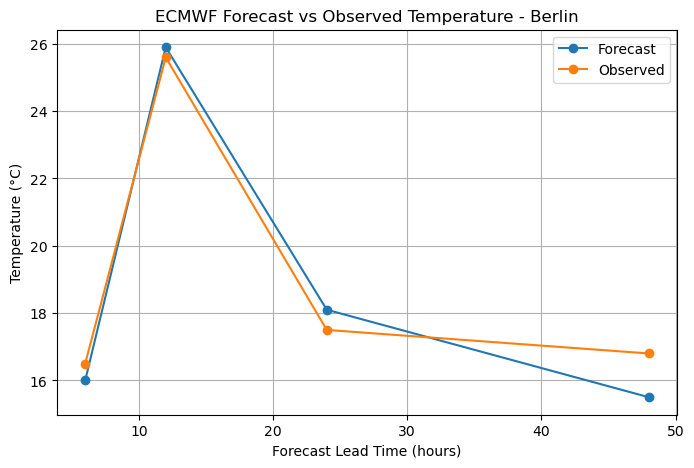

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["temperature_forecast_c"],
    marker="o",
    label="Forecast"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["temperature_observed_c"],
    marker="o",
    label="Observed"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Temperature (°C)")
plt.title("ECMWF Forecast vs Observed Temperature - Berlin")
plt.legend()
plt.grid(True)
plt.show()


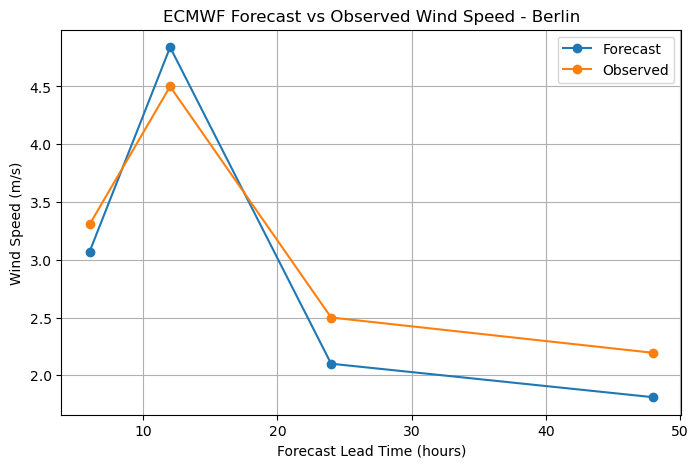

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["wind_speed_forecast_ms"],
    marker="o",
    label="Forecast"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["wind_speed_observed_ms"],
    marker="o",
    label="Observed"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Wind Speed (m/s)")
plt.title("ECMWF Forecast vs Observed Wind Speed - Berlin")
plt.legend()
plt.grid(True)
plt.show()


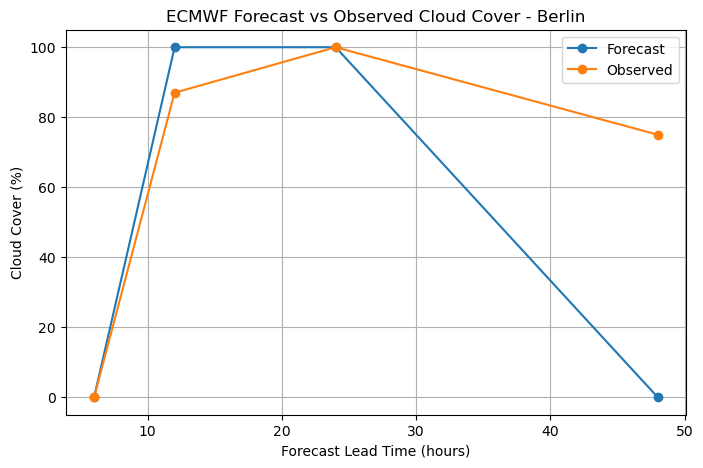

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["cloud_cover_forecast_pct"],
    marker="o",
    label="Forecast"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["cloud_cover_observed_pct"],
    marker="o",
    label="Observed"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Cloud Cover (%)")
plt.title("ECMWF Forecast vs Observed Cloud Cover - Berlin")
plt.legend()
plt.grid(True)
plt.show()


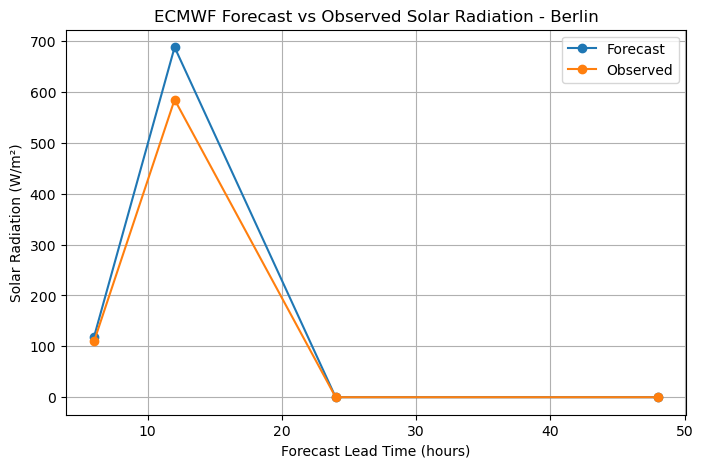

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["solar_radiation_forecast_wm2"],
    marker="o",
    label="Forecast"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["solar_radiation_observed_wm2"],
    marker="o",
    label="Observed"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Solar Radiation (W/m²)")
plt.title("ECMWF Forecast vs Observed Solar Radiation - Berlin")
plt.legend()
plt.grid(True)
plt.show()


## Renewable Energy Impact Analysis

Two simple normalized proxies are used to show how weather forecast errors can affect renewable-energy estimates.

These are demonstration proxies only. They do not represent a real wind turbine or solar installation.


### Wind Power Proxy

A simple piecewise power curve is used:

- below 3 m/s: no generation
- 3-12 m/s: generation increases with wind speed
- 12-25 m/s: normalized rated generation
- above 25 m/s: shutdown

The result is normalized between 0 and 1.


In [69]:
def wind_power_proxy(wind_speed):

    if wind_speed < 3:
        return 0

    elif wind_speed < 12:
        return ((wind_speed - 3) / 9) ** 3

    elif wind_speed <= 25:
        return 1

    else:
        return 0


In [70]:
berlin_verification["wind_power_forecast"] = (
    berlin_verification["wind_speed_forecast_ms"]
    .apply(wind_power_proxy)
)

berlin_verification["wind_power_observed"] = (
    berlin_verification["wind_speed_observed_ms"]
    .apply(wind_power_proxy)
)

berlin_verification["wind_power_error"] = (
    berlin_verification["wind_power_forecast"]
    - berlin_verification["wind_power_observed"]
)

berlin_verification[
    [
        "lead_hours",
        "wind_speed_forecast_ms",
        "wind_speed_observed_ms",
        "wind_power_forecast",
        "wind_power_observed",
        "wind_power_error"
    ]
]


,lead_hours,wind_speed_forecast_ms,wind_speed_observed_ms,wind_power_forecast,wind_power_observed,wind_power_error
0,6,3.07,3.305556,4.705075e-07,0.000039,-0.000039
1,12,4.84,4.500000,8.545273e-03,0.004630,0.003916
2,24,2.10,2.500000,0.000000e+00,0.000000,0.000000
3,48,1.81,2.194444,0.000000e+00,0.000000,0.000000


### Solar Power Proxy

Solar radiation is divided by 1000 W/m² and limited to the range 0-1. This provides a simple normalized proxy rather than a physical PV model.


In [71]:
berlin_verification["solar_power_forecast"] = np.clip(
    berlin_verification["solar_radiation_forecast_wm2"] / 1000,
    0,
    1
)

berlin_verification["solar_power_observed"] = np.clip(
    berlin_verification["solar_radiation_observed_wm2"] / 1000,
    0,
    1
)

berlin_verification["solar_power_error"] = (
    berlin_verification["solar_power_forecast"]
    - berlin_verification["solar_power_observed"]
)

berlin_verification[
    [
        "lead_hours",
        "solar_radiation_forecast_wm2",
        "solar_radiation_observed_wm2",
        "solar_power_forecast",
        "solar_power_observed",
        "solar_power_error"
    ]
]


,lead_hours,solar_radiation_forecast_wm2,solar_radiation_observed_wm2,solar_power_forecast,solar_power_observed,solar_power_error
0,6,119.0,110.0,0.119,0.110,0.009
1,12,688.0,585.0,0.688,0.585,0.103
2,24,0.0,0.0,0.000,0.000,0.000
3,48,0.0,0.0,0.000,0.000,0.000


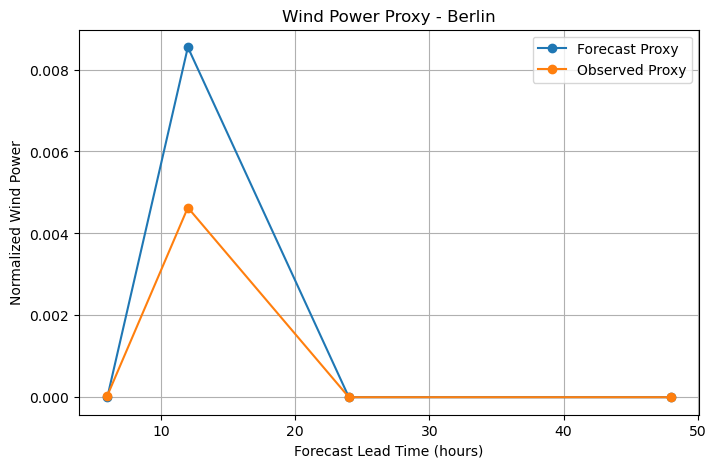

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["wind_power_forecast"],
    marker="o",
    label="Forecast Proxy"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["wind_power_observed"],
    marker="o",
    label="Observed Proxy"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Normalized Wind Power")
plt.title("Wind Power Proxy - Berlin")
plt.legend()
plt.grid(True)
plt.show()


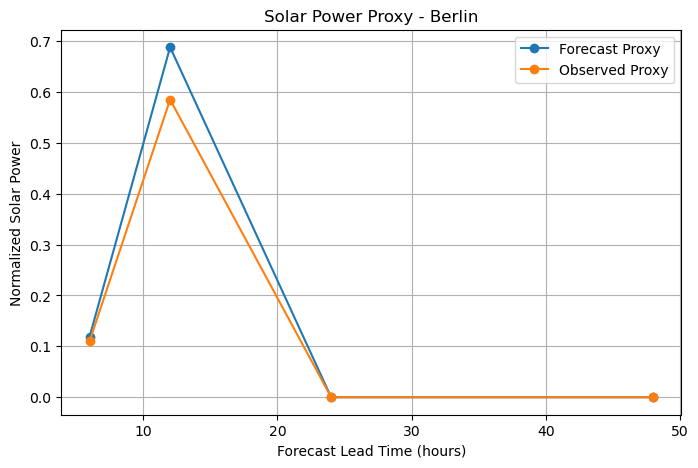

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["solar_power_forecast"],
    marker="o",
    label="Forecast Proxy"
)

plt.plot(
    berlin_verification["lead_hours"],
    berlin_verification["solar_power_observed"],
    marker="o",
    label="Observed Proxy"
)

plt.xlabel("Forecast Lead Time (hours)")
plt.ylabel("Normalized Solar Power")
plt.title("Solar Power Proxy - Berlin")
plt.legend()
plt.grid(True)
plt.show()


## Key Findings

For the small Berlin verification sample:

- Temperature errors were relatively small across the four cases.
- Wind-speed errors were also small in this sample.
- Cloud-cover errors were larger, particularly in the +48 hour case.
- The daytime solar-radiation forecast differed from the observed value.
- Wind and solar weather errors produced corresponding differences in the simplified renewable-energy proxies.

These findings apply only to this small demonstration sample.


## Limitations

This project has several important limitations:

- The detailed verification uses one Berlin forecast run with four lead times.
- One case at each lead time is not enough to measure a general lead-time accuracy trend.
- The correlation values are based on only four observations and should be interpreted cautiously.
- ECMWF forecasts represent model grid points, while Bright Sky observations come from nearby DWD weather stations.
- The wind-power proxy does not represent a specific turbine or wind farm.
- The solar-power proxy does not include panel angle, efficiency, temperature, shading or other real PV-system characteristics.
- The project demonstrates the verification workflow rather than providing a comprehensive assessment of ECMWF forecast skill.


## Conclusion

This project demonstrates a student-level weather forecast verification workflow using real meteorological data.

ECMWF GRIB data were processed with ecCodes, cfgrib and xarray. Temperature, wind speed, cloud cover and solar radiation were extracted for selected German locations and multiple forecast horizons.

A historical ECMWF forecast run for Berlin was then matched with observed DWD weather data using forecast valid time. Forecast errors were evaluated using MAE, RMSE, Bias and Correlation.

Finally, simple wind and solar generation proxies were used to show how weather forecast errors can influence renewable-energy estimates.

The project demonstrates the main concepts of GRIB processing, spatial extraction, time alignment, forecast verification and simplified renewable-energy impact analysis without claiming to model a real power plant.
